# Configuration

In [1]:
%run _dev_setup.py

🔁 Autoreload is ON (IPython detected).
✅ Using winners_curse from: /Users/iamsikun/Desktop/research/winners-curse/src/winners_curse


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [7]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 14
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from winners_curse.dgp import DataGenerationProcess, MNLAssortment
from winners_curse.variables import *
from winners_curse.structural import * 
from winners_curse.utils import *

/Users/iamsikun/Desktop/research/winners-curse/src/winners_curse/structural.py:36: SyntaxWarning: invalid escape sequence '\s'
  l(\beta) = \sum_{i=1}^{N} \log(p_{i})


# DGP

In [5]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.09 + i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

dgp = MNLAssortment(**dgp_params)

In [6]:
purchase_records = dgp.sample(100, seed=0)

# Estimation

In [7]:
emp_effects_arr = estimate_fixed_effects(purchase_records, dgp.n_products)

# Optimization

In [8]:
assortment, val_est = optimize(emp_effects_arr, int(dgp.n_products / 2))

# Evaluation

In [9]:
val_est = obj_func(emp_effects_arr, assortment)
val_true = obj_func(dgp.prod_fixed_effects, assortment)

result_df = pd.DataFrame({
    'Top-k Assortment': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Top-k Assortment
Estimated Policy Value,0.865671
True Policy Value,0.826592
Winner's Curse,0.039079


In [10]:
del val_est, val_true, result_df, assortment, emp_effects_arr, purchase_records, dgp

# Winner's Curse

In [34]:
dgp_params = {
    'prod_fe_vars': [PointMass(8 + i * 0.01) for i in range(100)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 5000}

estimators_dict = {}

In [ ]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True,
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


In [33]:
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_avg = wc_measures_dict[f'{optimizer}_nc_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer}_nc_wc_se']

    val_true_avg = wc_measures_dict[f'{optimizer}_nc_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer}_nc_val_true_se']
    val_est_avg = wc_measures_dict[f'{optimizer}_nc_val_est_avg']
    val_est_se = wc_measures_dict[f'{optimizer}_nc_val_est_se']

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Top 50%:
  - Average True Value: 0.9999 (0.0000)
  - Average Estimated Value: 0.9999 (0.0000)
  - Average Winner's Curse (%): -0.01% (0.22%)


# Estimating Winner's Curse

In [23]:
dgp = MNLAssortment(**dgp_params)
purchase_records = dgp.sample(500, seed=13)

In [24]:
emp_effects_arr = estimate_fixed_effects(purchase_records, dgp.n_products)

## Standard Bootstrap

In [25]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    n_bootstraps=500, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 437 out of 500 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


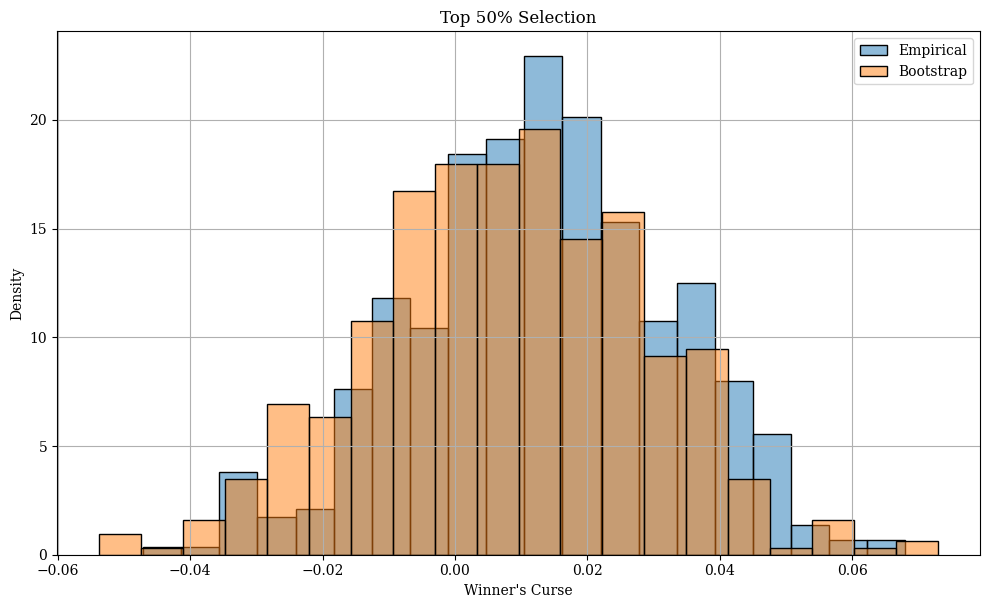

In [26]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [27]:
boot_wc_dstn_dict = get_wc_moon_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    n_bootstraps=500, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 437 out of 500 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


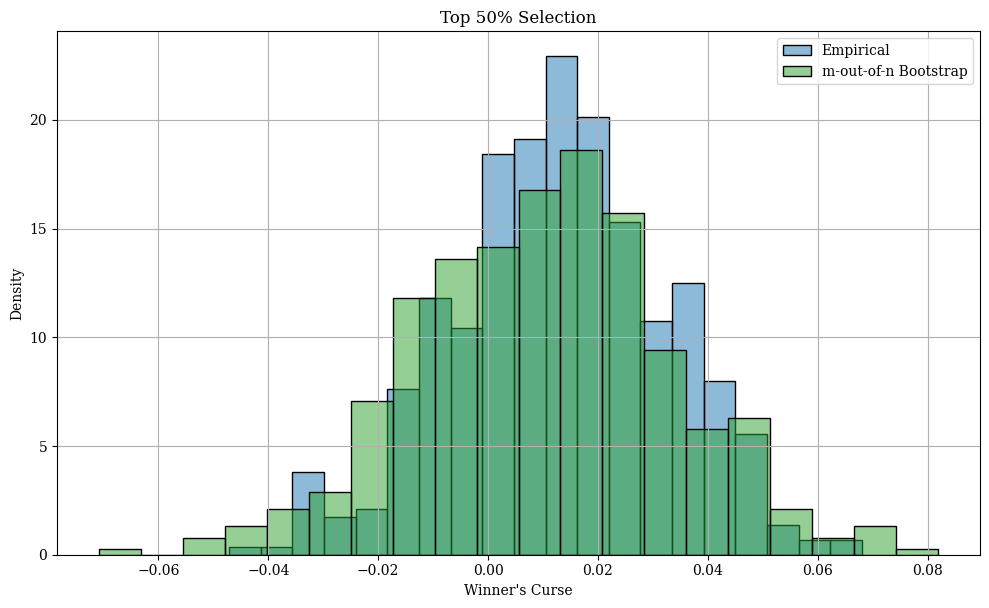

In [28]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [29]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    power=-0.45, 
    n_bootstraps=500, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


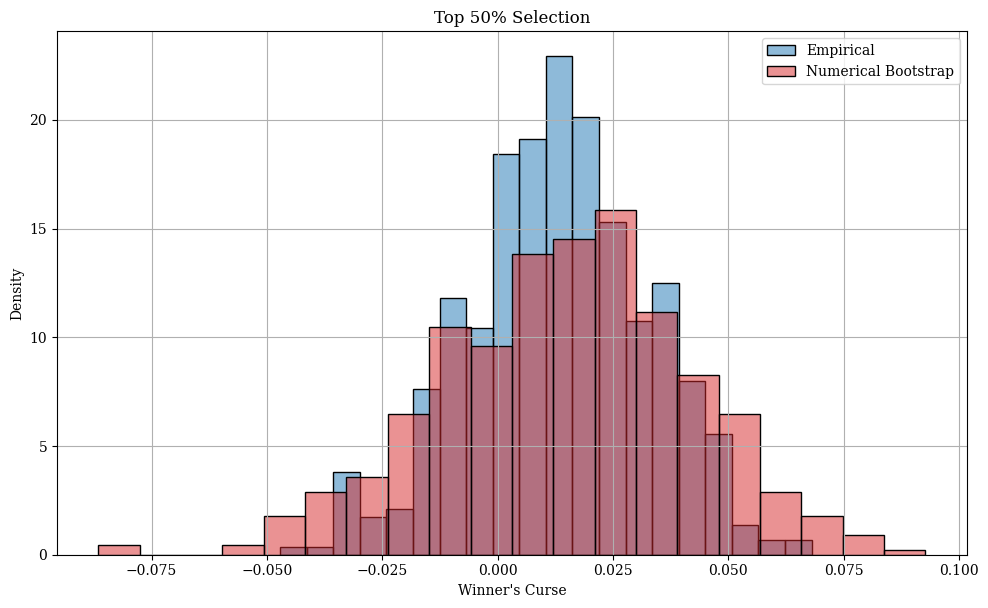

In [30]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [31]:
del dgp, purchase_records, emp_effects_arr, boot_wc_dstn_dict

# Bias Correction

In [23]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 5000}

estimators_dict = {
    # 'standard_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
    #     'display_name': 'Standard Bootstrap', 
    # }, 
    # 'moon_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'moon', 'n_jobs': 1}, 
    #     'display_name': 'm-out-of-n Bootstrap', 
    # },
    # 'numerical_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
    #     'display_name': 'Numerical Bootstrap', 
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    # 'bayesian': {
    #     'estimator': bayesian_mnl_estimate,
    #     'params': {'n_draws': 1000, 'n_warmup': 500},
    #     'display_name': 'Bayesian',
    # }, 
}

In [24]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True,
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1224 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 2624 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 4424 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    7.2s finished


In [25]:
# with open('results/mnl_assort_bias_correction.pkl', 'wb') as f:
#     pickle.dump(wc_measures_dict, f)

# with open('results/mnl_assort_bias_correction.pkl', 'rb') as f:
#     wc_measures_dict = pickle.load(f)


Selection with Top 50%:
Policy Value: 
  - True Value: 0.8333 (0.0001)
  - No Correction: 0.8467 (0.0009)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 133.56% (9.15%)
Median Winner's Curse: 
  - No Correction: 137.33% (9.15%)

Sample Splitting: 
  - True Value: 0.8332 (0.0001)
  - Estimated Value: 0.8329 (0.0014)
  - Winner's Curse (%): -4.17% (14.30%)


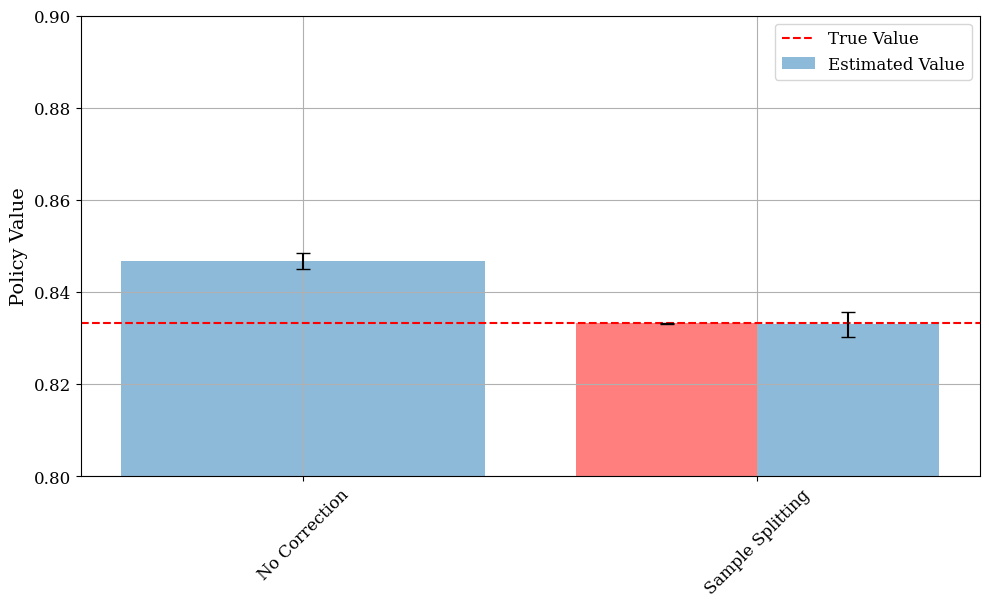

In [26]:
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

optimizer_key = 'top-0.5'
print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

own_policy_estimators = [key for key in estimators_dict.keys() if f'{optimizer_key}_{key}_val_true_avg' in wc_measures_dict.keys()]
focal_policy_estimators = [key for key in estimators_dict.keys() if key not in own_policy_estimators]

# true policy value of the focal policy
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + focal_policy_estimators:
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'
    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + focal_policy_estimators:
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'
    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + focal_policy_estimators:
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'
    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

for estimator in own_policy_estimators:
    display_name = estimators_dict[estimator]['display_name']
    print(f'\n{display_name}: ')
    val_true_avg = wc_measures_dict[f'{optimizer_key}_{estimator}_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer_key}_{estimator}_val_true_se']
    val_est_avg = wc_measures_dict[f'{optimizer_key}_{estimator}_val_est_avg']
    val_est_se = wc_measures_dict[f'{optimizer_key}_{estimator}_val_est_se']
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator}_wc_se']

    print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(1 + len(focal_policy_estimators))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + focal_policy_estimators
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + focal_policy_estimators
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
for idx, estimator_name in enumerate(own_policy_estimators):
    bar_width = 0.4
    ax.bar(
        bar_positions[-1] + idx + 1 - bar_width / 2, 
        wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_true_avg'], 
        yerr=1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_true_se'], 
        capsize=5, color='red', width=bar_width, alpha=0.5
    )
    ax.bar(
        bar_positions[-1] + idx + 1 + bar_width / 2,
        wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg'],
        yerr=1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se'],
        capsize=5, color='C0', width=bar_width, alpha=0.5
    )

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(1 + len(focal_policy_estimators) + len(own_policy_estimators)), 
    labels=['No Correction'] + [estimators_dict[k]['display_name'] for k in focal_policy_estimators] + [estimators_dict[k]['display_name'] for k in own_policy_estimators],
    rotation=45, 
    fontsize=tick_label_size
)

ax.set_ylim([0.8, 0.9])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [9]:
optimizer_key= 'top-0.5'
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean
latex_dict = {}

# true value
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
latex_dict["True Value"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${val_true_avg:.4f}$\\\\ (${val_true_se:.4f}$)" + "\end{tabular}", 
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${0:.2f}\%$\\\\ (${0:.2f}\%$)" + "\end{tabular}"
}

for e_key in ['nc'] + list(estimators_dict.keys()):
    if e_key == 'sample_splitting':
        continue
    
    est_mean = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_se']

    wc_mean = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_avg']
    wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_se']
    wc_sig_level = significance_level(wc_mean, wc_se)
    wc_sig_level = '^{' + wc_sig_level + '}' if wc_sig_level != '' else ''

    e_name =  estimators_dict[e_key]['display_name'] if e_key != 'nc' else 'No Correction'

    latex_dict[e_name] = {
        'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${est_mean:.4f}" + f"$\\\\ (${est_se:.4f}$)" + "\end{tabular}", 
        r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + wc_sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    }

# sample splitting
ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']

ss_wc_avg = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
ss_wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']
ss_wc_sig_level = significance_level(ss_wc_avg, ss_wc_se)
ss_wc_sig_level = '^{' + ss_wc_sig_level + '}' if ss_wc_sig_level != '' else ''
latex_dict["Sample Splitting"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_est_avg:.4f}" + f"$\\\\ (${ss_val_est_se:.4f}$)" + "\end{tabular}",
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_wc_avg:.2f}\%" + ss_wc_sig_level + f"$\\\\ (${ss_wc_se:.2f}\%$)" + "\end{tabular}"
}

latex_df = pd.DataFrame(latex_dict).T
print(latex_df.style.to_latex(
    column_format='ccc',  
    hrules=True
))

\begin{tabular}{ccc}
\toprule
 & Policy Value & \begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular} \\
\midrule
True Value & \begin{tabular}[c]{@{}c@{}}$0.8334$\\ ($0.0001$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.00\%$\\ ($0.00\%$)\end{tabular} \\
No Correction & \begin{tabular}[c]{@{}c@{}}$0.8466$\\ ($0.0009$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$132.56\%^{***}$\\ ($8.69\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.8375$\\ ($0.0009$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$41.30\%^{***}$\\ ($9.27\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.8355$\\ ($0.0009$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$21.16\%^{**}$\\ ($9.36\%$)\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.8347$\\ ($0.0010$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$13.09\%$\\ ($9.55\%$)\end{tabular} \\
Bayesian & \begin{tabular}[c]{@{}c@{}}$0.8465$\\ ($0.0009$)\end{tabular} & \begin{tabular}[c]{@{

In [28]:
nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = np.max([var.mean for var in dgp_params['prod_fe_vars']])
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = np.mean([var.mean for var in dgp_params['prod_fe_vars']])
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
print(policy_comp_df.style.to_latex(
    column_format='cc',  
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & Policy Value \\
\midrule
Clairvoyant Policy & -0.4100 \\
Focal Policy & \begin{tabular}[c]{@{}c@{}}$0.7608$\\ ($0.0002$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$0.7608$\\ ($0.0002$)\end{tabular} \\
Random Guessing & -0.4550 \\
\bottomrule
\end{tabular}



# Comparative Statics

## Hyperparameters

In [39]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 2500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    },
    'moon_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': np.nan, 'bootstrap_method': 'moon', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': np.nan, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
}

hyperparams_list = [(0.99, -0.49), (0.95, -0.45), (0.90, -0.40), (0.85, -0.35)]


In [40]:
hyperparams_result_dict = {param: None for param in hyperparams_list}

for mn_pow, num_pow in hyperparams_list:
    print(f'\nRunning with m-out-of-n power: {mn_pow}, numerical power: {num_pow}')

    estimators_dict['moon_bootstrap']['params']['power'] = mn_pow
    estimators_dict['numerical_bootstrap']['params']['power'] = num_pow

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    hyperparams_result_dict[(mn_pow, num_pow)] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Running with m-out-of-n power: 0.99, numerical power: -0.49
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Running with m-out-of-n power: 0.95, numerical power: -0.45
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   43.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Running with m-out-of-n power: 0.9, numerical power: -0.4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   43.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Running with m-out-of-n power: 0.85, numerical power: -0.35
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.4min finished


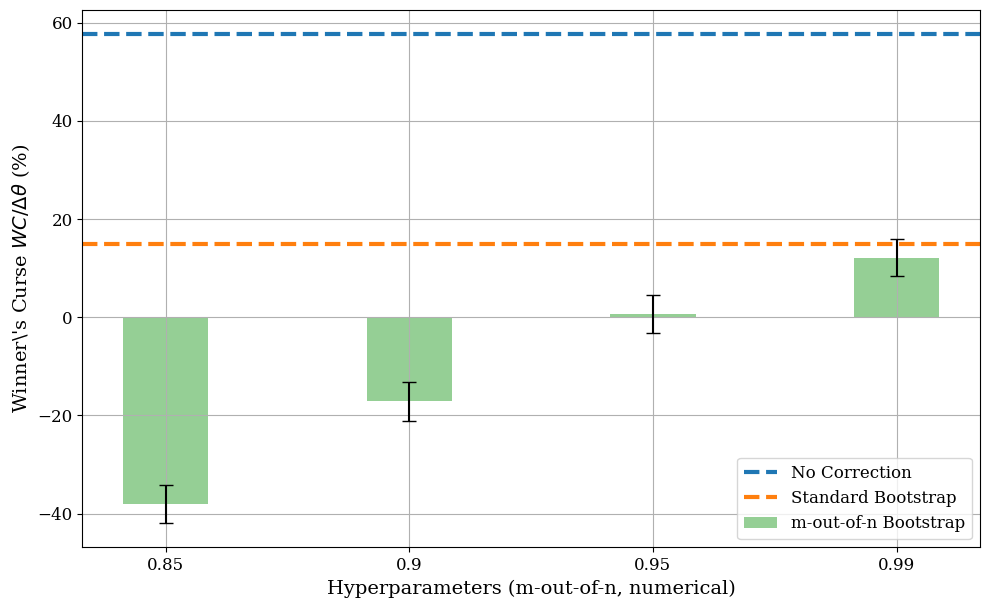

$\Delta\tau=(0.99, -0.49)$  \
No Correction        Mean                         57.64   
                     Median                       62.00   
                     S.E.                          1.87   
Standard Bootstrap   Mean                         14.93   
                     Median                       19.30   
                     S.E.                          1.95   
m-out-of-n Bootstrap Mean                         12.18   
                     Median                       15.53   
                     S.E.                          1.95   
Numerical Bootstrap  Mean                         12.20   
                     Median                       16.83   
                     S.E.                          1.95   

                             $\Delta\tau=(0.95, -0.45)$  \
No Correction        Mean                         57.64   
                     Median                       62.00   
                     S.E.                          1.87   
Standard Bootstrap   Mean                         14.93   
                     Median                       19.30   
                     S.E.                          1.95   
m-out-of-n Bootstrap Mean                          0.61   
                     Median                        3.82   
                     S.E.                          1.97   
Numerical Bootstrap  Mean                         -4.00   
                     Median                       -1.93   
                     S.E.                          1.98   

                             $\Delta\tau=(0.9, -0.4)$  \
No Correction        Mean                       57.64   
                     Median                     62.00   
                     S.E.                        1.87   
Standard Bootstrap   Mean                       14.93   
                     Median                     19.30   
                     S.E.                        1.95   
m-out-of-n Bootstrap Mean                      -17.16   
                     Median                    -13.78   
                     S.E.                        1.98   
Numerical Bootstrap  Mean                      -31.60   
                     Median                    -29.41   
                     S.E.                        2.05   

                             $\Delta\tau=(0.85, -0.35)$  
No Correction        Mean                         57.64  
                     Median                       62.00  
                     S.E.                          1.87  
Standard Bootstrap   Mean                         14.93  
                     Median                       19.30  
                     S.E.                          1.95  
m-out-of-n Bootstrap Mean                        -38.01  
                     Median                      -35.85  
                     S.E.                          2.00  
Numerical Bootstrap  Mean                        -71.15  
                     Median                      -71.08  
                     S.E.                          2.16

In [47]:
# parameters
optimizer_key = 'top-0.5'
result_dict = hyperparams_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for params_tup in hyperparams_list:
    data[params_tup] = {}

    data[params_tup]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[params_tup][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[params_tup][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[params_tup][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[params_tup][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[params_tup][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[params_tup][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[params_tup][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for params_tupe in hyperparams_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[params_tupe][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in hyperparams_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plot no correction as horizontal line
default_hyperparams = (0.95, -0.45)
nc_mean = 100 / delta_tau * result_dict[default_hyperparams][f'{optimizer_key}_nc_wc_avg']
nc_se = 100 / delta_tau * result_dict[default_hyperparams][f'{optimizer_key}_nc_wc_se']
ax.axhline(nc_mean, color='C0', linestyle='--', label='No Correction', linewidth=3)

standard_bootstrap_mean = 100 / delta_tau * result_dict[default_hyperparams][f'{optimizer_key}_standard_bootstrap_wc_avg']
standard_bootstrap_se = 100 / delta_tau * result_dict[default_hyperparams][f'{optimizer_key}_standard_bootstrap_wc_se']
ax.axhline(standard_bootstrap_mean, color='C1', linestyle='--', label='Standard Bootstrap', linewidth=3)


bar_values = [data[dt]['m-out-of-n Bootstrap']['Mean'] for dt in hyperparams_list]
bar_errors = [1.96 * data[dt]['m-out-of-n Bootstrap']['S.E.'] for dt in hyperparams_list]
bar_positions = np.arange(len(hyperparams_list))
bar_width = 0.35
ax.bar(
    bar_positions,
    bar_values[::-1], yerr=bar_errors[::-1], capsize=5,
    label='m-out-of-n Bootstrap', alpha=0.5, width=bar_width,
    color='C2'
)

ax.set_xlabel('Hyperparameters (m-out-of-n, numerical)', fontsize=axis_label_size)
ax.set_ylabel(r'Winner\'s Curse $WC / \Delta\theta$ (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(hyperparams_list)), labels=[item[0] for item in hyperparams_list][::-1], 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.savefig('figures/mnl_assort_hyperparams.jpg')
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Delta tau

In [15]:
dgp_params = {
    'prod_fe_vars': [None] * 10, 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 2500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'moon_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'moon', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    # 'numerical_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
    #     'display_name': 'Numerical Bootstrap', 
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'bayesian': {
        'estimator': bayesian_mnl_estimate,
        'params': {'n_draws': 1000, 'n_warmup': 500},
        'display_name': 'Bayesian',
    }, 
}

delta_tau_list = [0.00, 0.005, 0.01, 0.02]

### Base = -0.05

In [ ]:
base_effect = -0.05

delta_tau_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta Tau: {delta_tau}')

    dgp_params['prod_fe_vars'] = [PointMass(base_effect + delta_tau * i) for i in range(10)]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    delta_tau_result_dict[delta_tau] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

In [31]:
# with open('results/mnl_assort_delta_tau.pkl', 'wb') as f:
#     pickle.dump(delta_tau_result_dict, f)

with open('results/mnl_assort_delta_tau.pkl', 'rb') as f:
    delta_tau_result_dict = pickle.load(f)

In [36]:
delta_tau_result_dict[0.0]['top-0.5_nc_val_true_arr'].mean()

0.8262726822789994

In [38]:
delta_tau_result_dict[0.0]['top-0.5_bayesian_wc_arr'].mean()

0.006804813473300074

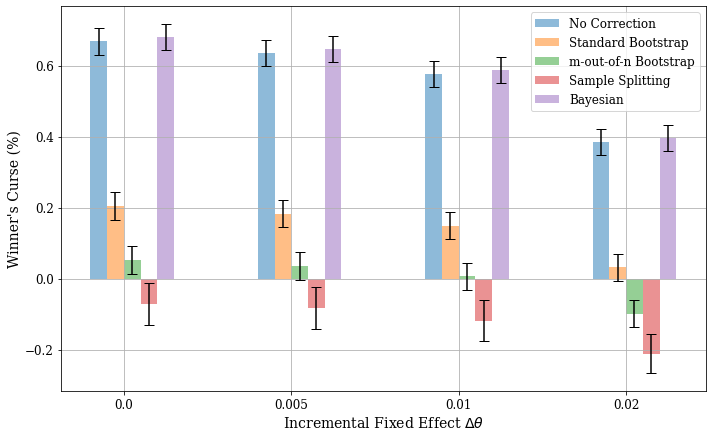

$\Delta\tau=0.0$  $\Delta\tau=0.005$  \
No Correction        Mean                0.67                0.63   
                     Median              0.72                0.69   
                     S.E.                0.02                0.02   
Standard Bootstrap   Mean                0.21                0.18   
                     Median              0.26                0.25   
                     S.E.                0.02                0.02   
m-out-of-n Bootstrap Mean                0.05                0.04   
                     Median              0.12                0.08   
                     S.E.                0.02                0.02   
Sample Splitting     Mean               -0.07               -0.08   
                     Median             -0.08               -0.15   
                     S.E.                0.03                0.03   
Bayesian             Mean                0.68                0.65   
                     Median              0.74                0.70   
                     S.E.                0.02                0.02   

                             $\Delta\tau=0.01$  $\Delta\tau=0.02$  
No Correction        Mean                 0.58               0.38  
                     Median               0.61               0.39  
                     S.E.                 0.02               0.02  
Standard Bootstrap   Mean                 0.15               0.03  
                     Median               0.19               0.05  
                     S.E.                 0.02               0.02  
m-out-of-n Bootstrap Mean                 0.01              -0.10  
                     Median               0.04              -0.08  
                     S.E.                 0.02               0.02  
Sample Splitting     Mean                -0.12              -0.21  
                     Median              -0.14              -0.17  
                     S.E.                 0.03               0.03  
Bayesian             Mean                 0.59               0.40  
                     Median               0.63               0.40  
                     S.E.                 0.02               0.02

In [17]:
# parameters
optimizer_key = 'top-0.5'
result_dict = delta_tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Incremental Fixed Effect $\Delta\theta$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [19]:
# parameters
optimizer_key = 'top-0.5'
result_dict = delta_tau_result_dict.copy()

stats = 'mean'  # mean or median
decimals = 4

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    wc_arr = 100 * result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']
    if stats == 'mean':
        wc_stats = np.nanmean(wc_arr)
        wc_sd = np.nanstd(wc_arr)
        data[delta_tau]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"{wc_stats:.{decimals}f}" + f"\\\\ ({wc_sd:.{decimals}f})" + "\end{tabular}" 

    elif stats == 'median':
        wc_stats = np.nanmedian(wc_arr)
        data[delta_tau]['No Correction'] = f"{wc_stats:.{decimals}f}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        wc_arr = 100 * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr']
        if stats == 'mean':
            wc_stats = np.nanmean(wc_arr)
            wc_sd = np.nanstd(wc_arr)
            data[delta_tau][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"{wc_stats:.{decimals}f}" + f"\\\\ ({wc_sd:.{decimals}f})" + "\end{tabular}"
        elif stats == 'median':
            wc_stats = np.nanmedian(wc_arr)
            data[delta_tau][est_name] = f"{wc_stats:.{decimals}f}"
            

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\Delta\\theta={delta_tau:.3f}$' for delta_tau in delta_tau_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & $\Delta\theta=0.000$ & $\Delta\theta=0.005$ & $\Delta\theta=0.010$ & $\Delta\theta=0.020$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}0.6687\\ (0.9513)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.6349\\ (0.9435)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.5766\\ (0.9328)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.3842\\ (0.9394)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}0.2054\\ (0.9908)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.1830\\ (0.9846)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.1496\\ (0.9714)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0327\\ (0.9758)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}0.0539\\ (1.0036)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0350\\ (0.9959)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0063\\ (0.9826)\end{tabular} & \begin{tabular}[c]{@{}c@{}}-0.0982\\ (0.9902)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}-0.0722\\ (1.5115)\end{tabular} &

### Base = -0.1

In [32]:
base_effect = -0.1

delta_tau_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta Tau: {delta_tau}')

    dgp_params['prod_fe_vars'] = [PointMass(base_effect + delta_tau * i) for i in range(10)]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    delta_tau_result_dict[delta_tau] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta Tau: 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   47.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta Tau: 0.025
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   46.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta Tau: 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   48.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.1min
c:\Users\xusik\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.6min finished


In [33]:
with open('results/mnl_assort_delta_tau_1e-1.pkl', 'wb') as f:
    pickle.dump(delta_tau_result_dict, f)

with open('results/mnl_assort_delta_tau_1e-1.pkl', 'rb') as f:
    delta_tau_result_dict = pickle.load(f)

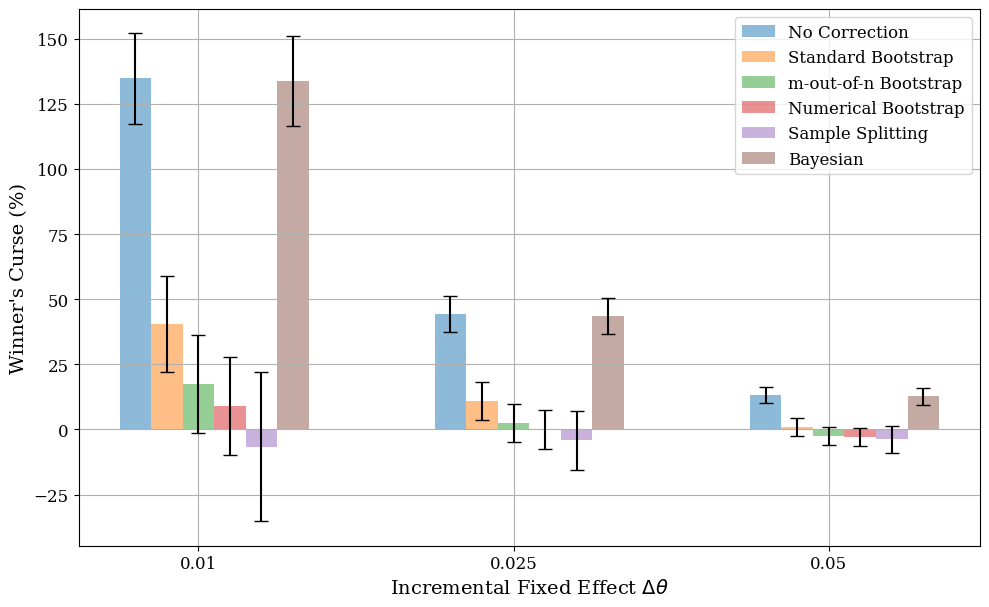

$\Delta\tau=0.01$  $\Delta\tau=0.025$  \
No Correction        Mean               134.71               44.36   
                     Median             136.56               43.95   
                     S.E.                 8.83                3.52   
Standard Bootstrap   Mean                40.62               11.03   
                     Median              44.25                8.57   
                     S.E.                 9.43                3.75   
m-out-of-n Bootstrap Mean                17.57                2.53   
                     Median              21.42                2.45   
                     S.E.                 9.55                3.80   
Numerical Bootstrap  Mean                 9.13                0.12   
                     Median              10.99               -0.18   
                     S.E.                 9.63                3.83   
Sample Splitting     Mean                -6.57               -4.08   
                     Median               9.99                1.06   
                     S.E.                14.63                5.75   
Bayesian             Mean               133.67               43.60   
                     Median             137.48               42.95   
                     S.E.                 8.77                3.51   

                             $\Delta\tau=0.05$  
No Correction        Mean                13.25  
                     Median              13.08  
                     S.E.                 1.64  
Standard Bootstrap   Mean                 1.00  
                     Median               1.33  
                     S.E.                 1.73  
m-out-of-n Bootstrap Mean                -2.47  
                     Median              -3.00  
                     S.E.                 1.75  
Numerical Bootstrap  Mean                -2.81  
                     Median              -3.98  
                     S.E.                 1.76  
Sample Splitting     Mean                -3.74  
                     Median              -4.96  
                     S.E.                 2.61  
Bayesian             Mean                12.74  
                     Median              12.24  
                     S.E.                 1.63

In [34]:
# parameters
optimizer_key = 'top-0.5'
result_dict = delta_tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Incremental Fixed Effect $\Delta\theta$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Capacity

In [5]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': None}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 2500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'moon_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'moon', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    # 'numerical_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
    #     'display_name': 'Numerical Bootstrap', 
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'bayesian': {
        'estimator': bayesian_mnl_estimate,
        'params': {'n_draws': 1000, 'n_warmup': 500},
        'display_name': 'Bayesian',
    }, 
}
capacity_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
capacity_result_dict = {capacity: None for capacity in capacity_list}

for capacity in capacity_list:
    print(f'\nCapacity: {capacity}')

    optimization_params['top-0.5']['params']['capacity'] = capacity

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    capacity_result_dict[capacity] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Capacity: 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   42.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Capacity: 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   36.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Capacity: 3
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   41.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Capacity: 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   40.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Capacity: 9
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.3min finished


In [6]:
# with open('results/mnl_assort_capacity.pkl', 'wb') as f:
#     pickle.dump(capacity_result_dict, f)

with open('../results/mnl_assort_capacity.pkl', 'rb') as f:
    capacity_result_dict = pickle.load(f)

<>:93: SyntaxWarning: invalid escape sequence '\$'
<>:93: SyntaxWarning: invalid escape sequence '\$'
/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_23178/1667765829.py:93: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel('Winner\'s Curse Per 100 Customers (\$)', fontsize=axis_label_size)


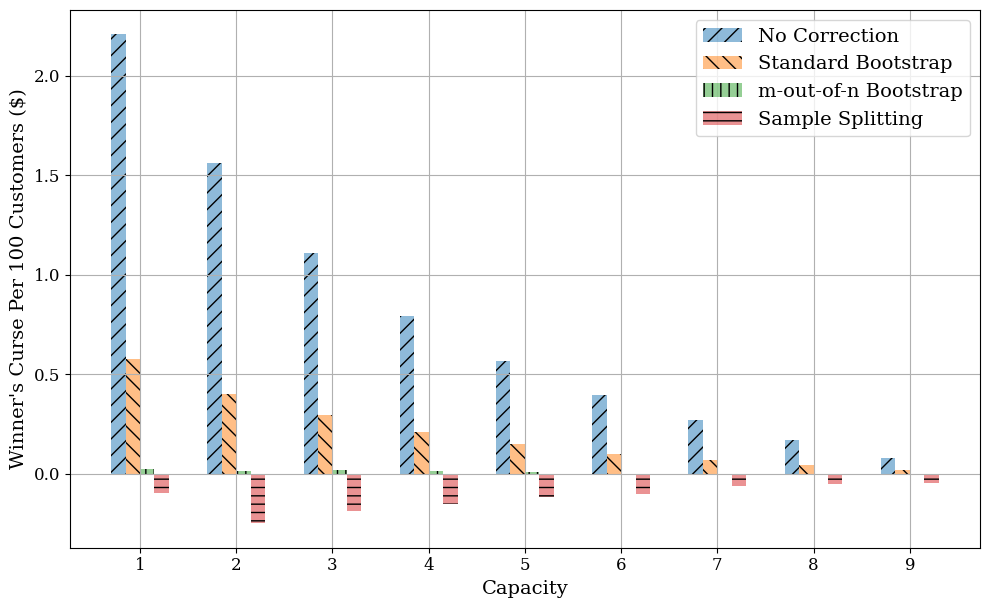

Capacity=1  Capacity=2  Capacity=3  Capacity=4  \
No Correction        Mean          2.21        1.56        1.11        0.79   
                     Median        2.17        1.58        1.14        0.83   
                     S.E.          0.04        0.03        0.03        0.02   
Standard Bootstrap   Mean          0.57        0.40        0.30        0.21   
                     Median        0.47        0.41        0.34        0.25   
                     S.E.          0.04        0.03        0.03        0.02   
m-out-of-n Bootstrap Mean          0.02        0.01        0.02        0.01   
                     Median       -0.09        0.05        0.03        0.03   
                     S.E.          0.04        0.03        0.03        0.02   
Sample Splitting     Mean         -0.10       -0.25       -0.19       -0.15   
                     Median       -0.17       -0.30       -0.16       -0.18   
                     S.E.          0.07        0.05        0.04        0.03   

                             Capacity=5  Capacity=6  Capacity=7  Capacity=8  \
No Correction        Mean          0.57        0.40        0.27        0.17   
                     Median        0.61        0.41        0.30        0.20   
                     S.E.          0.02        0.02        0.01        0.01   
Standard Bootstrap   Mean          0.15        0.10        0.07        0.04   
                     Median        0.19        0.11        0.10        0.05   
                     S.E.          0.02        0.02        0.02        0.01   
m-out-of-n Bootstrap Mean          0.01       -0.00       -0.00       -0.00   
                     Median        0.04        0.01        0.00        0.01   
                     S.E.          0.02        0.02        0.02        0.01   
Sample Splitting     Mean         -0.12       -0.10       -0.06       -0.05   
                     Median       -0.14       -0.08       -0.05       -0.07   
                     S.E.          0.03        0.03        0.02        0.02   

                             Capacity=9  
No Correction        Mean          0.08  
                     Median        0.11  
                     S.E.          0.01  
Standard Bootstrap   Mean          0.02  
                     Median        0.04  
                     S.E.          0.01  
m-out-of-n Bootstrap Mean         -0.00  
                     Median        0.01  
                     S.E.          0.01  
Sample Splitting     Mean         -0.05  
                     Median       -0.04  
                     S.E.          0.02

In [12]:
# parameters
optimizer_key = 'top-0.5'
result_dict = capacity_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for capacity in capacity_list:
    data[capacity] = {}

    data[capacity]['No Correction'] = {
        'Mean': 100 * result_dict[capacity][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 * np.nanmedian(result_dict[capacity][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 * result_dict[capacity][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 * result_dict[capacity][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 * np.nanmedian(result_dict[capacity][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 * result_dict[capacity][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[capacity][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }


for capacity in capacity_list:
    data[capacity]['No Correction'] = data[capacity]['Bayesian']
    del data[capacity]['Bayesian']
estimator_names = estimator_names[:-1]

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for capacity in capacity_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[capacity][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=['Capacity={}'.format(p) for p in capacity_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(capacity_list))
bar_width = 0.15 * n_estimators

hatch_patterns = ['//', '\\\\', '||', '--']

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in capacity_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, 
        # yerr=bar_errors, 
        capsize=5, label=estimator, alpha=0.5, width=bar_width / n_estimators, 
        hatch=hatch_patterns[idx]
    )

ax.set_xlabel(r'Capacity', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse Per 100 Customers (\$)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(capacity_list)), labels=capacity_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.savefig('../figures/mnl_assort_capacity.pdf')
plt.show()

# delete all variables in this cell
# del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
# del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Sample Size

In [11]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.025) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': None}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'moon_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'moon', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'bayesian': {
        'estimator': bayesian_mnl_estimate,
        'params': {'n_draws': 1000, 'n_warmup': 500},
        'display_name': 'Bayesian',
    }, 
}

sample_size_list = [100, 1000, 2500, 5000, 10000]

In [ ]:
sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size: {sample_size}')

    data_params['sample_size'] = sample_size

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size: 100
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [12]:
# with open('results/mnl_assort_sample_size.pkl', 'wb') as f:
#     pickle.dump(sample_size_result_dict, f)

with open('results/mnl_assort_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

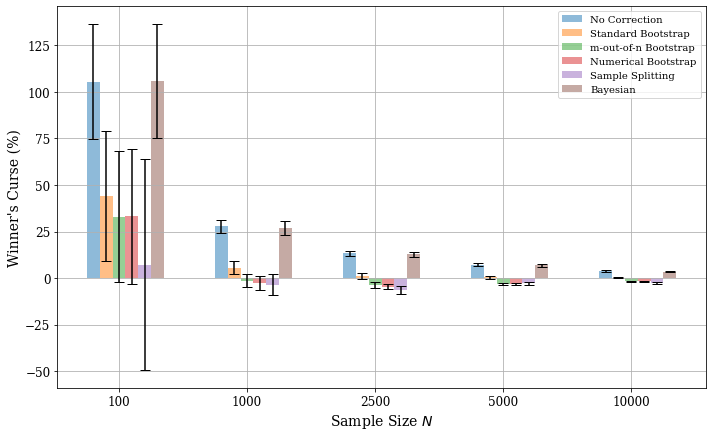

$N=100$  $N=1000$  $N=2500$  $N=5000$  $N=10000$
No Correction        Mean     105.36     27.70     13.28      7.23       3.72
                     Median   110.45     28.50     13.53      6.73       4.26
                     S.E.      15.80      1.79      0.74      0.35       0.19
Standard Bootstrap   Mean      44.08      5.62      0.99      0.32       0.28
                     Median    47.20      6.63      1.16      0.49       0.83
                     S.E.      17.68      1.87      0.76      0.36       0.19
m-out-of-n Bootstrap Mean      32.90     -1.31     -3.82     -3.11      -1.81
                     Median    37.68     -0.07     -3.24     -3.33      -1.30
                     S.E.      17.98      1.89      0.77      0.37       0.19
Numerical Bootstrap  Mean      33.07     -2.72     -4.53     -3.25      -1.69
                     Median    38.30     -3.00     -4.05     -3.36      -1.36
                     S.E.      18.36      1.91      0.77      0.37       0.19
Sample Splitting     Mean       7.16     -3.46     -6.16     -2.88      -2.43
                     Median    27.10      2.11     -7.36     -2.94      -2.22
                     S.E.      28.95      2.84      1.09      0.53       0.28
Bayesian             Mean     105.97     26.89     12.75      6.85       3.44
                     Median   111.61     27.61     13.35      6.33       3.83
                     S.E.      15.59      1.79      0.73      0.35       0.19

In [13]:
# parameters
optimizer_key = 'top-0.5'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [14]:
# parameters
optimizer_key = 'top-0.5'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{cccccc}
\toprule
 & $N=100$ & $N=1000$ & $N=2500$ & $N=5000$ & $N=10000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$105.36\%^{***}$\\ ($15.80\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$27.70\%^{***}$\\ ($1.79\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$13.28\%^{***}$\\ ($0.74\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.23\%^{***}$\\ ($0.35\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$3.72\%^{***}$\\ ($0.19\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$44.08\%^{**}$\\ ($17.68\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$5.62\%^{***}$\\ ($1.87\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.99\%$\\ ($0.76\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.32\%$\\ ($0.36\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.28\%$\\ ($0.19\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$32.90\%^{*}$\\ ($17.98\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-1.31\%$\\ ($1.89\%$)\end{tabular} & \begin{tabular